In [1]:
import base64
import os
from mistralai.client import Mistral
from dotenv import load_dotenv
from bs4 import BeautifulSoup
import json
load_dotenv("../../.env")

True

In [2]:
api_key = os.environ["MISTRAL_API_KEY"]

client = Mistral(api_key=api_key)

In [3]:
def encode_pdf(pdf_path):
    with open(pdf_path, "rb") as pdf_file:
        return base64.b64encode(pdf_file.read()).decode("utf-8")

In [4]:
ocr_response = client.ocr.process(
    model="mistral-ocr-latest",
    document={
        "type": "document_url",
        "document_url": f"data:application/pdf;base64,{encode_pdf('/Users/simon/dev/everything-training/src/mistral_ocr/data/simontest.pdf')}",
    },
    table_format="html",  # default is None
    # extract_header=True, # default is False
    # extract_footer=True, # default is False
    include_image_base64=True,
)

In [5]:
print(f"got response={ocr_response}")

got response=pages=[OCRPageObject(index=0, markdown="FACTURE\n\nA\n\nDECATHLON\n\nN° de commande FR17314668735\n\nDate de commande 05.01.25\n\nDate d'émission 06.01.25\n\nN° de Facture 1 25 0102 0000001433\n\nDECATHLON BATIGNOLLES\n\n153 rue cardinet\n\n17 eme\n\n75017 Paris\n\nSIRET : 44264635200108\n\n# ADRESSE DE FACTURATION\n\n# ADRESSE DE LIVRAISON\n\nSIMON THUAUC\n\n39 RUE DES FAISANS\n\nBAT 2 / ETAGE 2 DROITE\n\n75014 PARIS France\n\nSIMON THUAUD\n\n147bis rue Cardinet, ZAC Clichy Batignolles\n\n75017 PARIS France\n\nTous nos produits sur www.decathlon.fr !\n\n[tbl-0.html](tbl-0.html)\n\nTotal HT 1082.50 €\n\nMontant TVA 20 % 216.50 €\n\nPour acquit\n\nTotal TTC 1299.00 €\n\nCe(s) produit(s) bénéficie(nt) d'une garantie légale de conformité d'une durée de deux ans à compter de sa(leur) remise.\n\nNewmag SAS - 4 Bd de mons - Capital de 2 340 000 €\n\nN° TVA FR47 442 646 352 - 59650 VILLENEUVE D'ASCQ FRANCE", images=[], dimensions=OCRPageDimensions(dpi=87, height=1018, width=720),

In [6]:
print(ocr_response.pages[0].tables)

html_data = ocr_response.pages[0].tables[0].content


html_data

[OCRTableObject(id='tbl-0.html', content="<table><tr><th>Article</th><th>Référence</th><th>Quantité</th><th>PU TTC avant remise</th><th>Total TTC avant remise</th><th>Remise</th><th>Total HT après remise</th><th>% TVA</th><th>Montant TVA</th><th>Total TTC</th></tr><tr><td>VELO DE VILLE<br/>ELECTRIQUE ELOPS 900 E<br/>CADRE BAS BLEU FONCE<br/>Dont participation à l'écotaxe : 0.0 €</td><td>4996217</td><td>1</td><td>1,299</td><td>1,299</td><td>0.00</td><td>1082.50</td><td>20 %</td><td>216.50</td><td>1299.00</td></tr></table>", format_='html', word_confidence_scores=None)]


"<table><tr><th>Article</th><th>Référence</th><th>Quantité</th><th>PU TTC avant remise</th><th>Total TTC avant remise</th><th>Remise</th><th>Total HT après remise</th><th>% TVA</th><th>Montant TVA</th><th>Total TTC</th></tr><tr><td>VELO DE VILLE<br/>ELECTRIQUE ELOPS 900 E<br/>CADRE BAS BLEU FONCE<br/>Dont participation à l'écotaxe : 0.0 €</td><td>4996217</td><td>1</td><td>1,299</td><td>1,299</td><td>0.00</td><td>1082.50</td><td>20 %</td><td>216.50</td><td>1299.00</td></tr></table>"

In [7]:
table_data = [
    [cell.text for cell in row("td")] for row in BeautifulSoup(html_data)("tr")
]

In [8]:
table_data

[[],
 ["VELO DE VILLEELECTRIQUE ELOPS 900 ECADRE BAS BLEU FONCEDont participation à l'écotaxe : 0.0 €",
  '4996217',
  '1',
  '1,299',
  '1,299',
  '0.00',
  '1082.50',
  '20 %',
  '216.50',
  '1299.00']]

In [9]:
def html_table_to_json(html: str) -> list[dict]:
    """Convert the first HTML table found into a list of row dicts."""
    soup = BeautifulSoup(html, "html.parser")
    table = soup.find("table")
    if table is None:
        return []

    rows = table.find_all("tr")
    if not rows:
        return []

    # Headers: prefer <th>, fall back to first row's <td>
    header_cells = rows[0].find_all(["th", "td"])
    headers = [c.get_text(strip=True) for c in header_cells]

    data = []
    for row in rows[1:]:
        cells = row.find_all("td")
        if not cells:
            continue  # skip empty / separator rows
        values = [c.get_text(strip=True) for c in cells]
        data.append(dict(zip(headers, values)))

    return data

In [10]:
records = html_table_to_json(html=html_data)
records

[{'Article': "VELO DE VILLEELECTRIQUE ELOPS 900 ECADRE BAS BLEU FONCEDont participation à l'écotaxe : 0.0 €",
  'Référence': '4996217',
  'Quantité': '1',
  'PU TTC avant remise': '1,299',
  'Total TTC avant remise': '1,299',
  'Remise': '0.00',
  'Total HT après remise': '1082.50',
  '% TVA': '20 %',
  'Montant TVA': '216.50',
  'Total TTC': '1299.00'}]

In [11]:
ocr_response = client.ocr.process(
    model="mistral-ocr-latest",
    document={
        "type": "document_url",
        "document_url": f"data:application/pdf;base64,{encode_pdf('/Users/simon/dev/everything-training/src/mistral_ocr/data/testmultipages.pdf')}",
    },
    table_format="html",  # default is None
    # extract_header=True, # default is False
    # extract_footer=True, # default is False
    include_image_base64=True,
)


OCRResponse(pages=[OCRPageObject(index=0, markdown="Cycle Service\n\nCycle Service Lyon\n\n87 rue Jaboulay\n\n69007 Lyon\n\n+33 4 81 06 02 60\n\ncontact@cycleservice.fr\n\n# Facture\n\n![img-0.jpeg](img-0.jpeg)\n\nNuméro de facture 102003\nNuméro de client 113034\nDate de la facture 16-05-2026\n\nLéni Gauffier\n\nFrance\n06 44 73 15 09\n\n[tbl-0.html](tbl-0.html)\n\nTVA : FR47841381924 - N° SIREN : 841381924 - IBAN : FR15 3000 2010 0000 0071 3034 A72 - BIC: CRLYFRPP\n\nEn cas de retard de paiement, et conformément à l'article L. 441-6 du code du commerce, une indemnité calculée sur la base de trois fois le taux d'intérêt légal ainsi que des frais de recouvrement de 40 euros sont dus.", images=[OCRImageObject(id='img-0.jpeg', top_left_x=32, top_left_y=192, bottom_right_x=149, bottom_right_y=227, image_base64='', image_annotation=None)], dimensions=OCRPageDimensions(dpi=87, height=1018, width=720), tables=[OCRTableObject(id='tbl-0.html', content='<table><tr><th>Description</th><th>Quanti
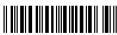

In [12]:
ocr_response

In [15]:
print(ocr_response.usage_info)

pages_processed=2 doc_size_bytes=38571
